In [ ]:
import pandas as pd
import requests
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import seaborn as sns
import scipy.stats as stats

In [ ]:
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-11-03/ikea.csv'
filename = 'ikea.csv'

if not os.path.exists(filename):
    print(f"Файл '{filename}' не знайдено. Спроба завантаження з URL...")
    response = requests.get(url)
    if response.status_code == 200:

        with open(filename, 'wb') as file:
            file.write(response.content)
        print(f"Файл завантажено та збережено як '{filename}'.")
    else:
        print(f"Не вдалося завантажити файл. Статус: {response.status_code}")
        exit()


df_ikea = pd.read_csv(filename)


df_ikea = df_ikea.drop_duplicates(subset=['item_id']).copy()

df_ikea


Файл 'ikea.csv' не знайдено. Спроба завантаження з URL...
Файл завантажено та збережено як 'ikea.csv'.


,Unnamed: 0,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,No old price,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",IKEA of Sweden/Ehlén Johansson,66.0,236.0,200.0
3689,3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,NaN,91.0
3690,3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,NaN,135.0
3691,3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,NaN,175.0


In [ ]:
display(df_ikea)
df_ikea.info()
df_ikea.describe()
df_unique_count = df_ikea.nunique()
print(df_unique_count)
df_ikea.isnull().sum()

,Unnamed: 0,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,No old price,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",IKEA of Sweden/Ehlén Johansson,66.0,236.0,200.0
3689,3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,NaN,91.0
3690,3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,NaN,135.0
3691,3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,NaN,175.0


<class 'pandas.core.frame.DataFrame'>
Index: 2962 entries, 0 to 3692
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2962 non-null   int64  
 1   item_id            2962 non-null   int64  
 2   name               2962 non-null   object 
 3   category           2962 non-null   object 
 4   price              2962 non-null   float64
 5   old_price          2962 non-null   object 
 6   sellable_online    2962 non-null   bool   
 7   link               2962 non-null   object 
 8   other_colors       2962 non-null   object 
 9   short_description  2962 non-null   object 
 10  designer           2962 non-null   object 
 11  depth              1844 non-null   float64
 12  height             2236 non-null   float64
 13  width              2520 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 326.9+ KB
Unnamed: 0           2962
item_id              2962
name 

,0
Unnamed: 0,0
item_id,0
name,0
category,0
price,0
old_price,0
sellable_online,0
link,0
other_colors,0
short_description,0


In [ ]:
#Data formating

# 1.Designers
def cleanDesigners(value, removeIKEA=False, emptyValue=np.nan):
    if not isinstance(value, str):
        return value

    if len(value) > 0 and value[0].isdigit():
        return emptyValue

    designers = value.split("/")

    if removeIKEA:
        try:
            designers.remove("IKEA of Sweden")
        except:
            pass
    if len(designers) > 0:
        return '/'.join(sorted(designers))
    else:
        return emptyValue

df_ikea['designer_clean'] = df_ikea['designer'].apply(cleanDesigners, args=(False, "IKEA of Sweden"))

# 2.Old_price
import re
def extract_price(value):
    if isinstance(value, str) and ',' in value:
        value = value.replace(',', '')

    if isinstance(value, (float)):
        return float(value)

    if isinstance(value, str):
        match = re.search(r'\d+\.?\d*', value)
        if match:

            return float(match.group(0))
        else:

            return np.nan

    return np.nan
df_ikea['old_price_clean'] = df_ikea['old_price'].apply(extract_price)
# print(pd.Series(df_ikea['old_price_clean'].unique()))

# 3.Delete column "Unnamed: 0"
df_ikea = df_ikea.drop('Unnamed: 0', axis=1)

In [ ]:
# Overview
display(df_ikea)
df_ikea.info()
df_ikea.describe()
df_unique_count = df_ikea.nunique()
print(df_unique_count)
df_ikea.isnull().sum()

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width,designer_clean,old_price_clean
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0,Nicholai Wiig Hansen,NaN
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0,Francis Cayouette,NaN
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN,Francis Cayouette,NaN
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0,Henrik Preutz,NaN
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0,Marcus Arvonen,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,No old price,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",IKEA of Sweden/Ehlén Johansson,66.0,236.0,200.0,Ehlén Johansson/IKEA of Sweden,NaN
3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,NaN,91.0,Ehlén Johansson,820.0
3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,NaN,135.0,Ehlén Johansson,1755.0
3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,NaN,175.0,Ehlén Johansson,1050.0


<class 'pandas.core.frame.DataFrame'>
Index: 2962 entries, 0 to 3692
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            2962 non-null   int64  
 1   name               2962 non-null   object 
 2   category           2962 non-null   object 
 3   price              2962 non-null   float64
 4   old_price          2962 non-null   object 
 5   sellable_online    2962 non-null   bool   
 6   link               2962 non-null   object 
 7   other_colors       2962 non-null   object 
 8   short_description  2962 non-null   object 
 9   designer           2962 non-null   object 
 10  depth              1844 non-null   float64
 11  height             2236 non-null   float64
 12  width              2520 non-null   float64
 13  designer_clean     2962 non-null   object 
 14  old_price_clean    574 non-null    float64
dtypes: bool(1), float64(5), int64(1), object(8)
memory usage: 350.0+ KB
item_id  

,0
item_id,0
name,0
category,0
price,0
old_price,0
sellable_online,0
link,0
other_colors,0
short_description,0
designer,0


In [ ]:
df_ikea.head(10)

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width,designer_clean,old_price_clean
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0,Nicholai Wiig Hansen,NaN
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0,Francis Cayouette,NaN
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN,Francis Cayouette,NaN
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0,Henrik Preutz,NaN
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0,Marcus Arvonen,NaN
5,10122647,INGOLF,Bar furniture,345.0,No old price,True,https://www.ikea.com/sa/en/p/ingolf-bar-stool-...,No,"Bar stool with backrest, 63 cm",Carina Bengs,45.0,91.0,40.0,Carina Bengs,NaN
6,70404875,FRANKLIN,Bar furniture,129.0,No old price,True,https://www.ikea.com/sa/en/p/franklin-bar-stoo...,No,"Bar stool with backrest, foldable, ...",K Hagberg/M Hagberg,44.0,95.0,50.0,K Hagberg/M Hagberg,NaN
7,60155602,DALFRED,Bar furniture,195.0,No old price,True,https://www.ikea.com/sa/en/p/dalfred-bar-stool...,No,"Bar stool, 63-74 cm",Sarah Fager,50.0,NaN,50.0,Sarah Fager,NaN
8,50406465,FRANKLIN,Bar furniture,129.0,No old price,True,https://www.ikea.com/sa/en/p/franklin-bar-stoo...,No,"Bar stool with backrest, foldable, ...",K Hagberg/M Hagberg,44.0,95.0,50.0,K Hagberg/M Hagberg,NaN
9,69304221,EKEDALEN / EKEDALEN,Bar furniture,2176.0,"SR 2,375",True,https://www.ikea.com/sa/en/p/ekedalen-ekedalen...,No,Bar table and 4 bar stools,Ehlén Johansson,NaN,NaN,NaN,Ehlén Johansson,2375.0


EDA

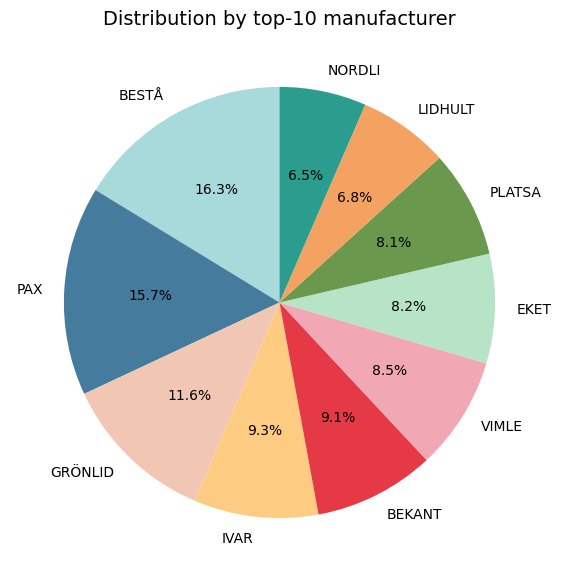

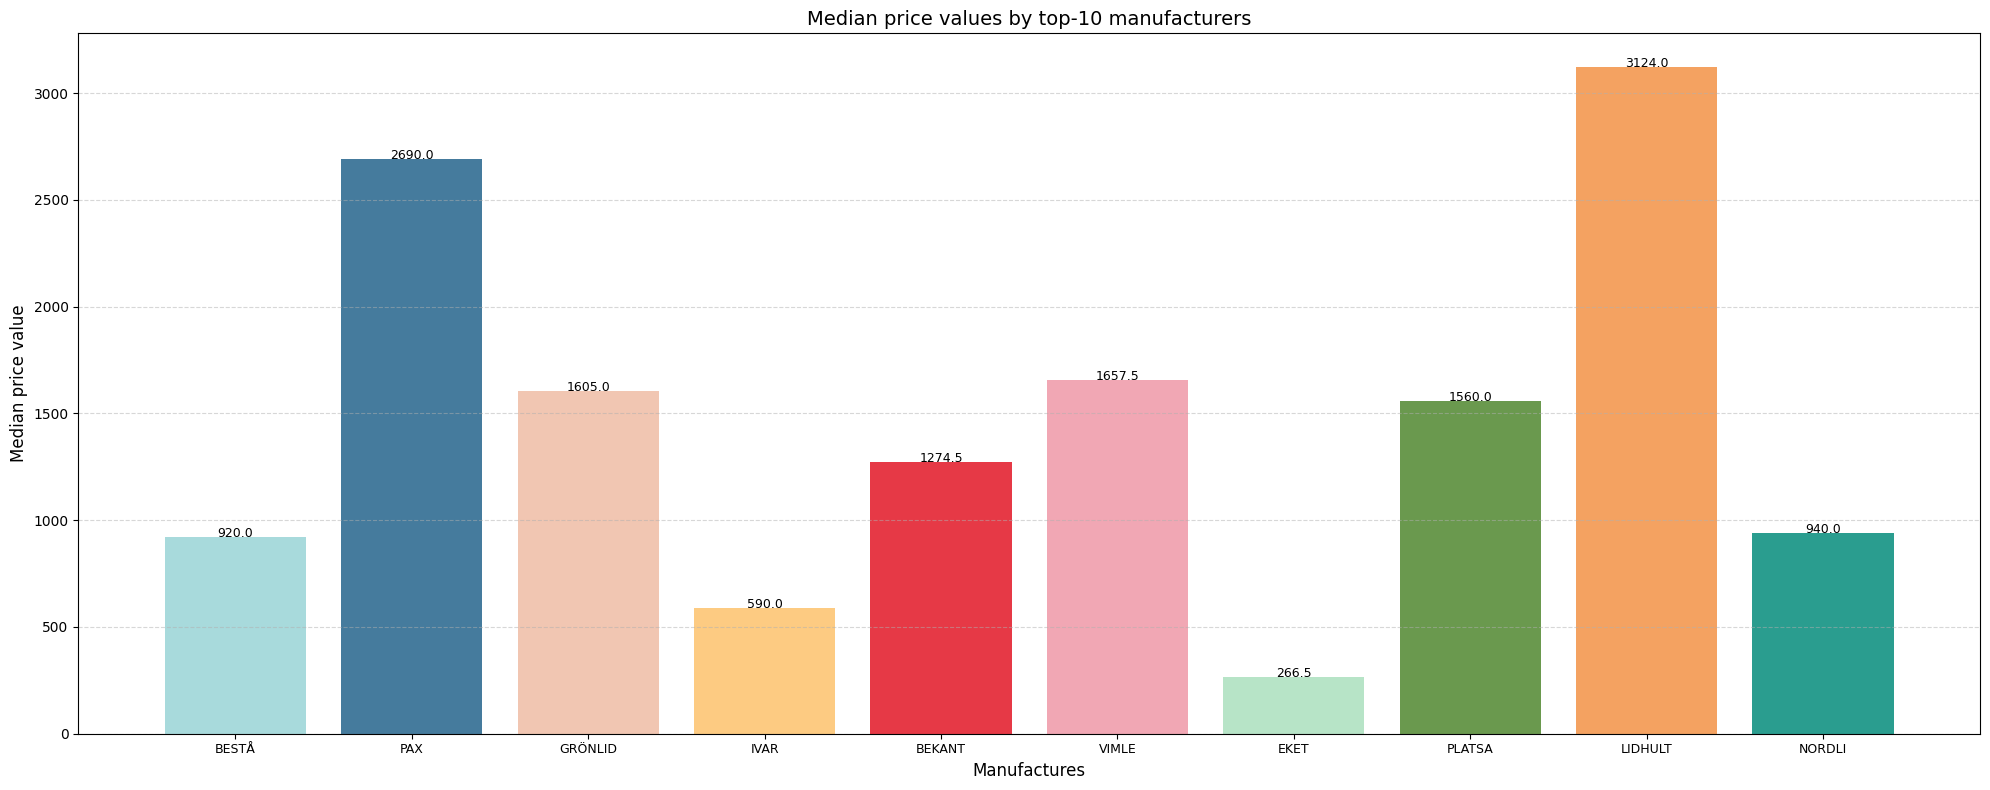

In [ ]:
df_name_count = df_ikea['name'].value_counts().head(10).reset_index()
# display(df_name_count)
colors = ['#A8DADC','#457B9D','#F1C6B2','#FDCB82','#E63946','#F1A7B4','#B7E4C7','#6A994E','#F4A261','#2A9D8F']
plt.figure(figsize=(12, 7))
df_name_count['count'].plot(kind='pie',labels=df_name_count['name'], colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution by top-10 manufacturer', fontsize=14)
plt.ylabel('')
plt.show()

df1 = df_ikea.groupby('name')['price'].median().sort_values(ascending=False).reset_index()
df2 = df_ikea['name'].value_counts().reset_index()
df_name_rank = pd.merge(df1, df2, on='name').sort_values(by='count', ascending=False).head(10)
# display(df_name_rank)

plt.figure(figsize=(20, 8))
bars = plt.bar(df_name_rank['name'], df_name_rank['price'], color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 1), ha='center', fontsize=9)

plt.title('Median price values by top-10 manufacturers', fontsize=14)
plt.xlabel('Manufactures', fontsize=12)
plt.ylabel('Median price value', fontsize=12)
plt.xticks(rotation=0, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

NameError: name 'mean' is not defined

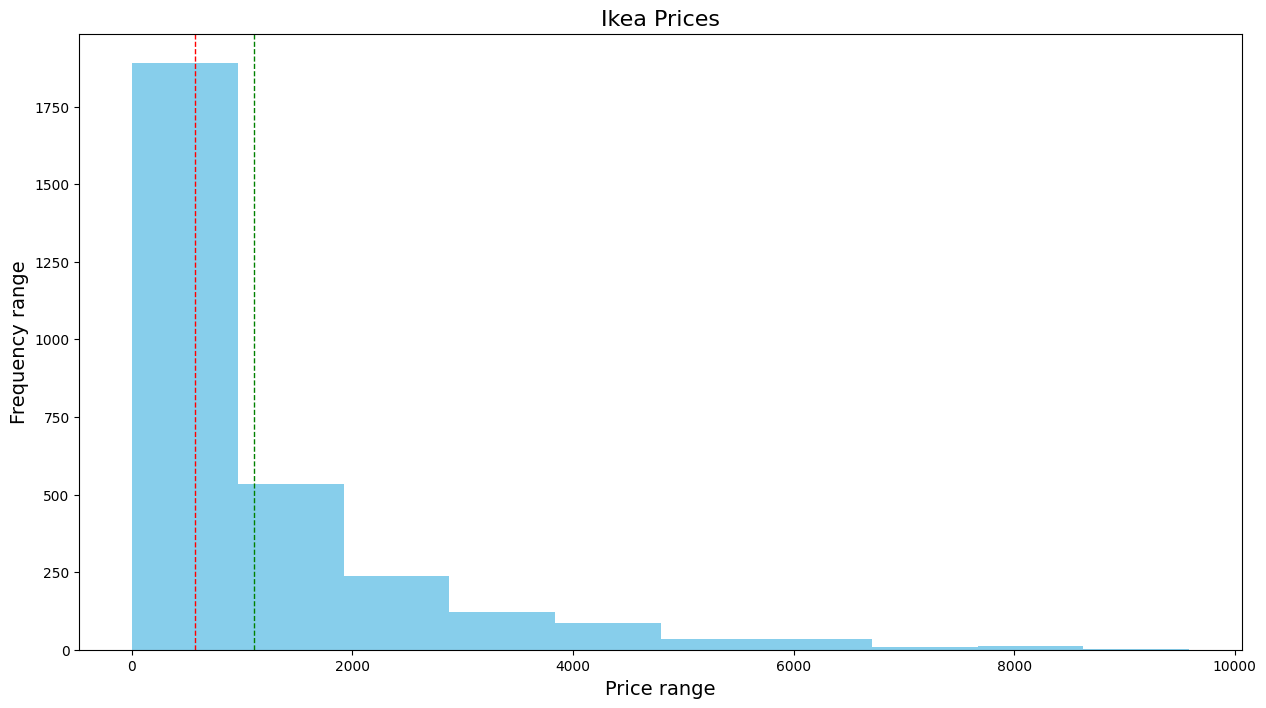

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(df_ikea["price"], bins=10, color='skyblue')
plt.title("Ikea Prices", fontsize=16)
plt.xlabel("Price range", fontsize=14)
plt.ylabel("Frequency range", fontsize=14)

plt.axvline(df_ikea["price"].mean(), color='g', linestyle='--', linewidth=1, label="mean: {:.1f}".format(df_ikea["price"].mean()))
plt.axvline(df_ikea["price"].median(), color='r', linestyle='dashed', linewidth=1,label="median: {:.1f}".format(df_ikea["price"].median()))


plt.text(df_ikea["price"].mean(), 2020, "mean", va="baseline")
plt.text(df_ikea["price"].median(), 2020, "median", va="baseline")

plt.grid(True, linestyle='--', alpha=0.8)
plt.xlim(0, 8500)
plt.legend()
plt.show()

mean price = 1108.7
median price = 570

> Добавить блок с цитатой



,category,price
0,Wardrobes,1950.0
1,Sofas & armchairs,1157.0
2,Beds,1093.5
3,"Sideboards, buffets & console tables",927.5
4,TV & media furniture,860.0
5,Cabinets & cupboards,845.0
6,Room dividers,595.0
7,Trolleys,537.0
8,Chests of drawers & drawer units,499.0
9,Chairs,497.0


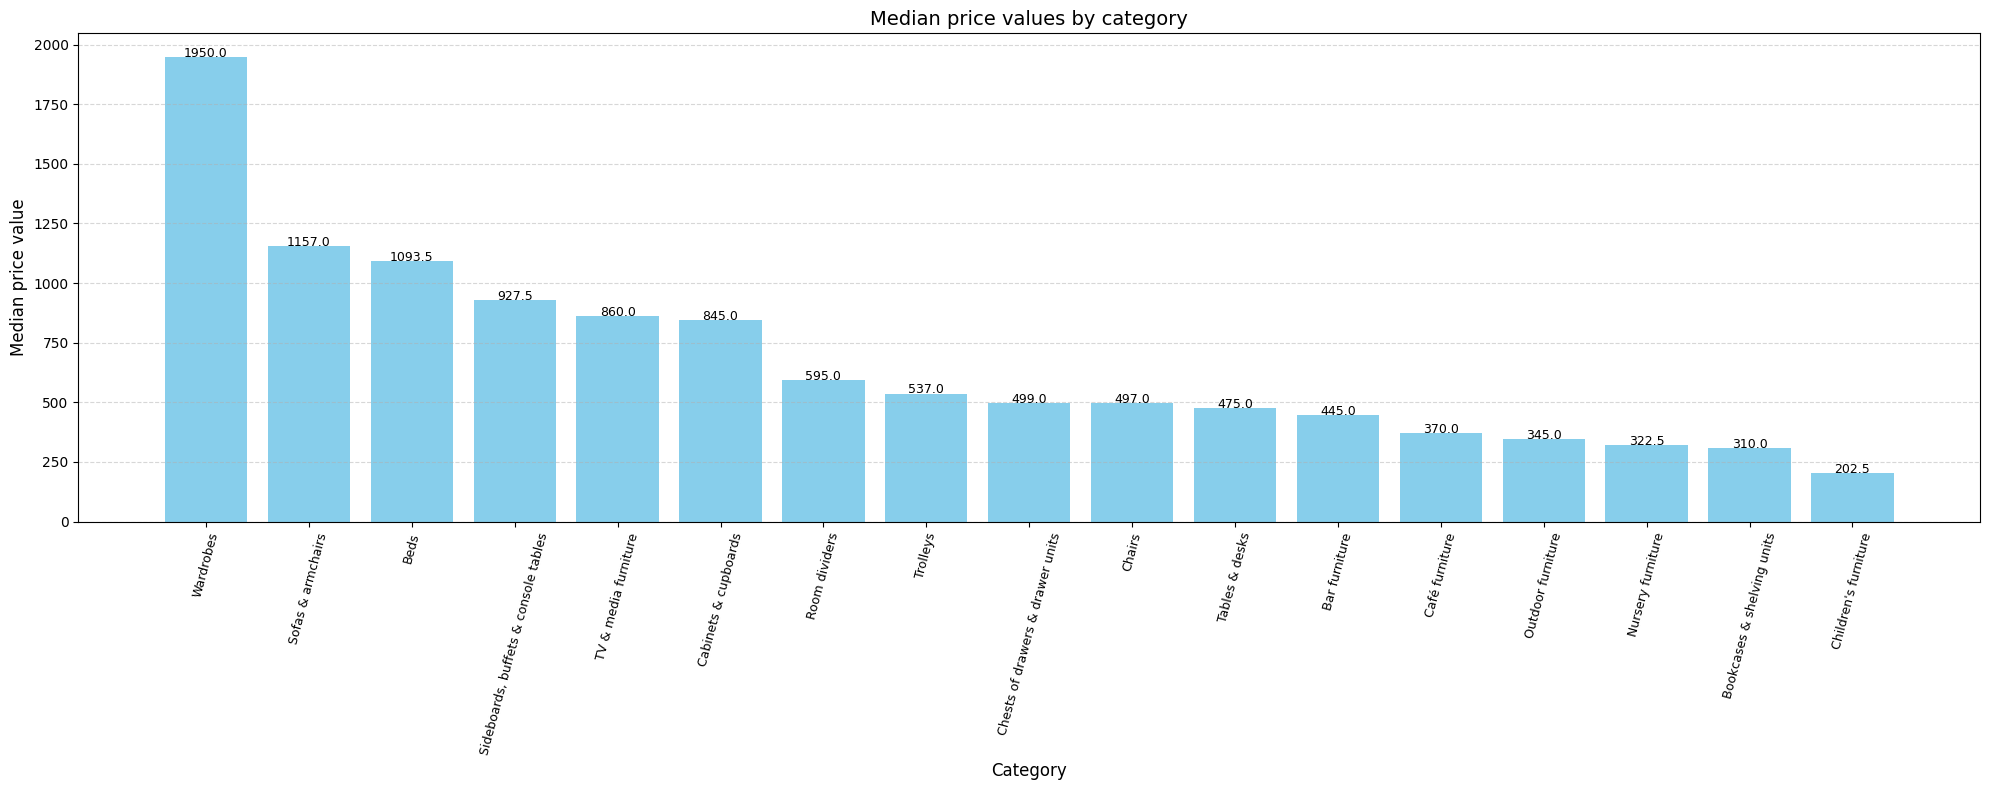

In [ ]:
df_category_rank = df_ikea.groupby('category')['price'].median().sort_values(ascending=False).reset_index()
display(df_category_rank)
plt.figure(figsize=(20, 8))
bars = plt.bar(df_category_rank['category'], df_category_rank['price'], color='skyblue')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 1), ha='center', fontsize=9)

plt.title('Median price values by category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Median price value', fontsize=12)
plt.xticks(rotation=75, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

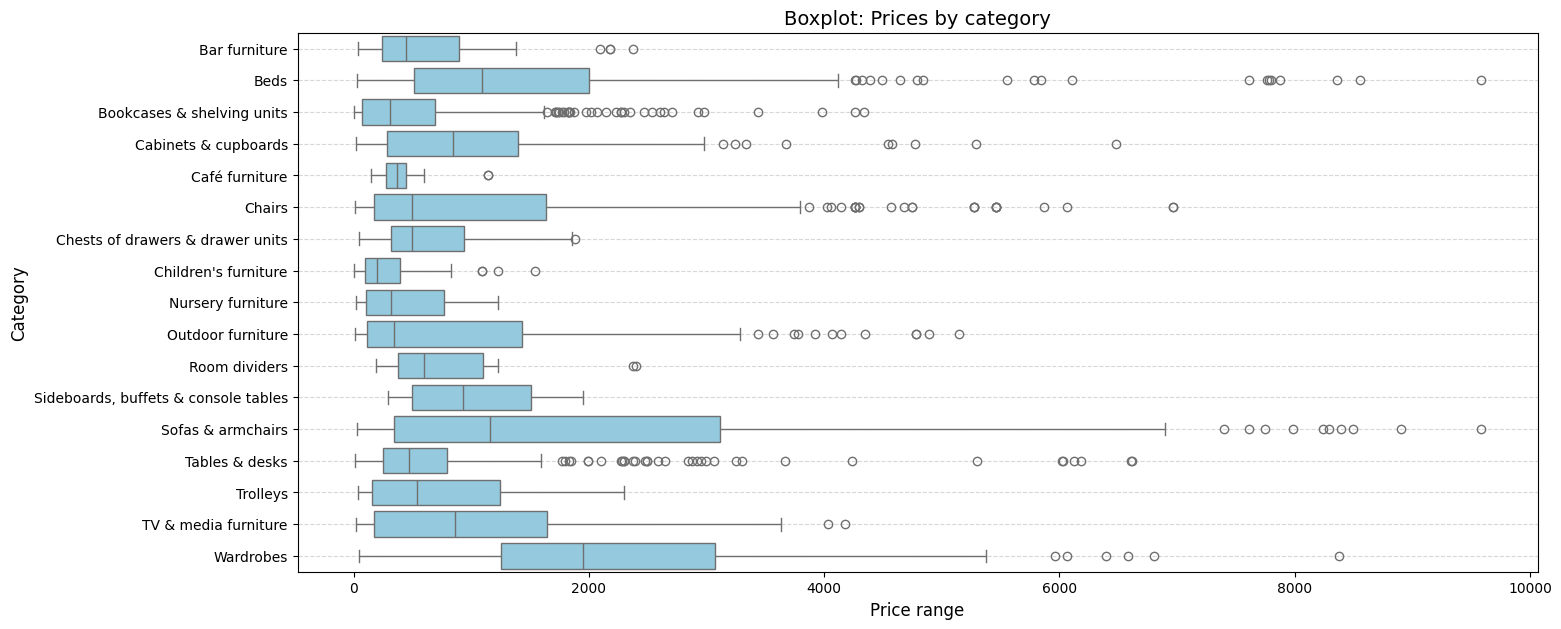

In [ ]:
plt.figure(figsize=(16,7))
sns.boxplot(x='price', y='category', data=df_ikea, color='skyblue')
plt.title('Boxplot: Prices by category', fontsize=14)
plt.xlabel('Price range', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


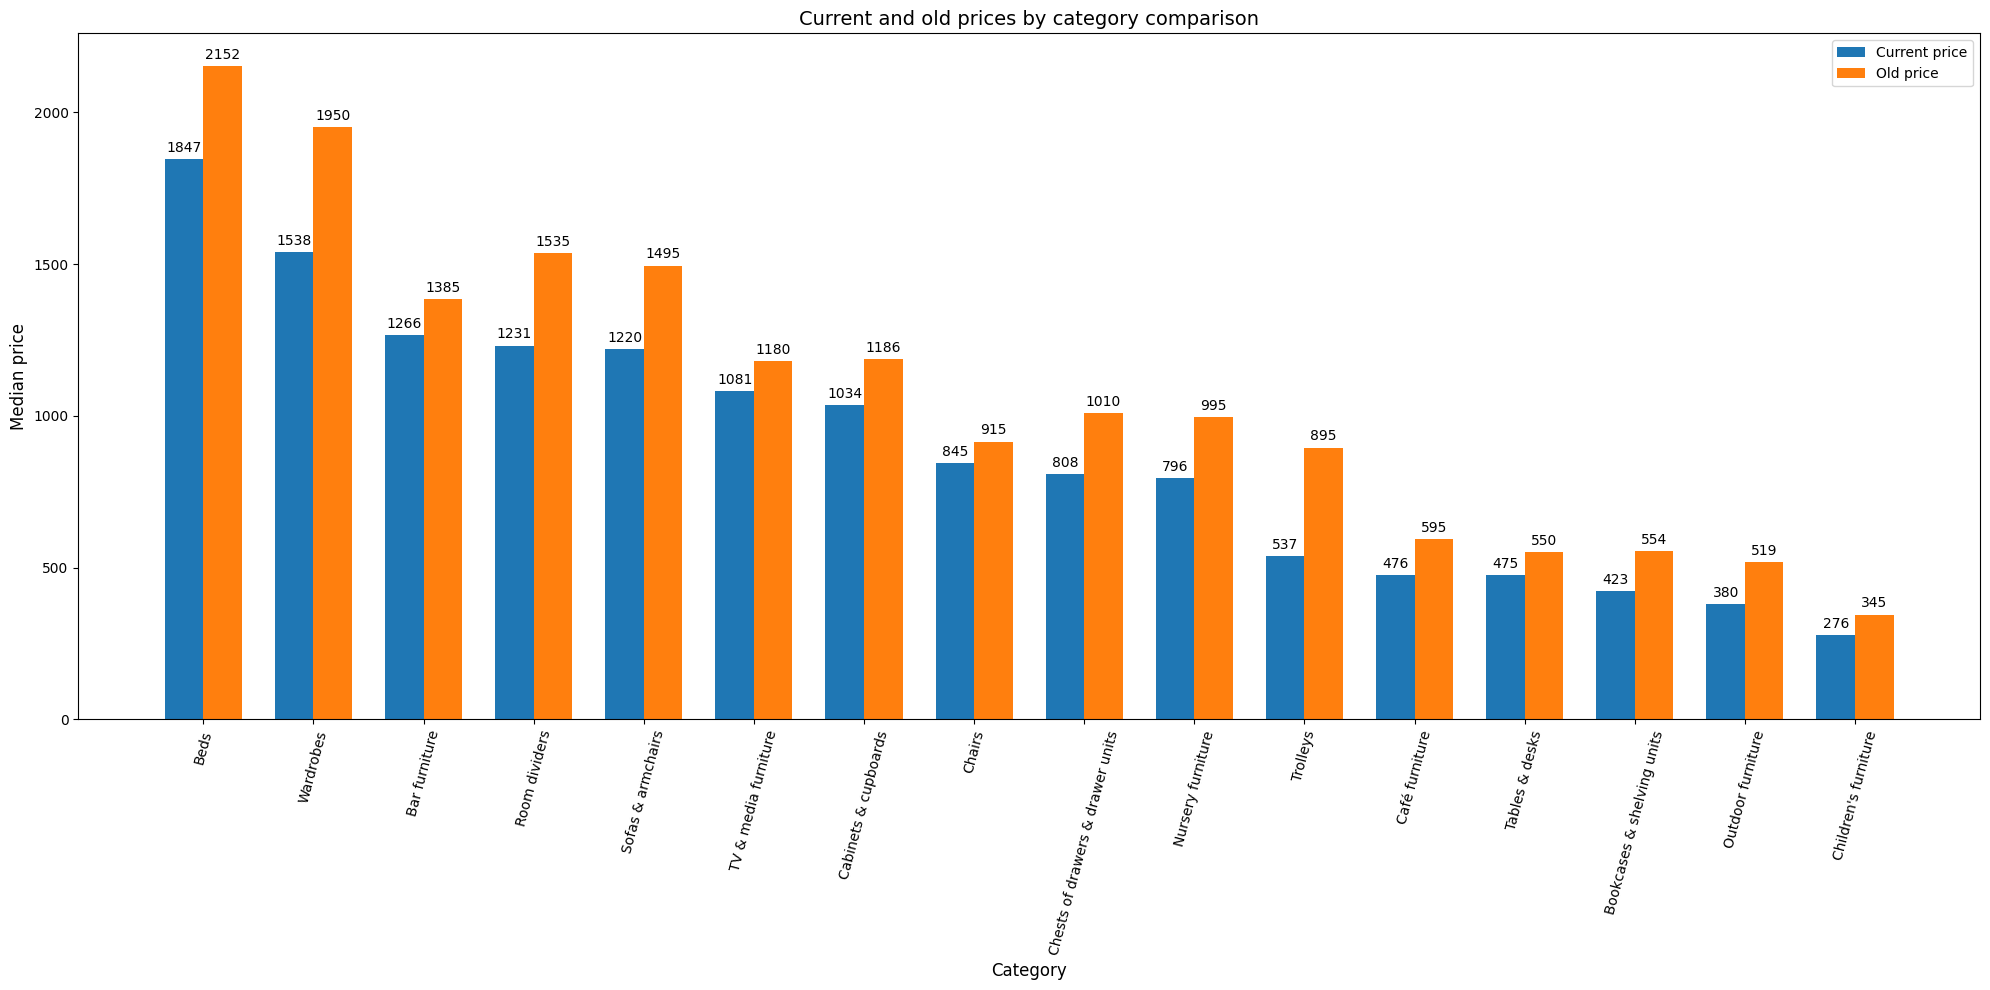

In [ ]:
df_old_price_clean = df_ikea[df_ikea['old_price_clean'].notna()]

df_1 = (
    df_old_price_clean
    .groupby('category')[['price', 'old_price_clean']]
    .median()
    .sort_values(by='price', ascending=False)
    .reset_index()
)
# display(df_1)

x = np.arange(len(df_1['category']))
width = 0.35

plt.figure(figsize=(20, 10))
ax = plt.axes()
bars1 = ax.bar(x - width/2, df_1['price'], width, label='Current price')
bars2 = ax.bar(x + width/2, df_1['old_price_clean'], width, label='Old price')

ax.bar_label(bars1, padding=3, fmt='%.0f')
ax.bar_label(bars2, padding=3, fmt='%.0f')

ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Median price', fontsize=12)
ax.set_title('Current and old prices by category comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_1['category'], rotation=75)
ax.legend()

plt.tight_layout()
plt.show()

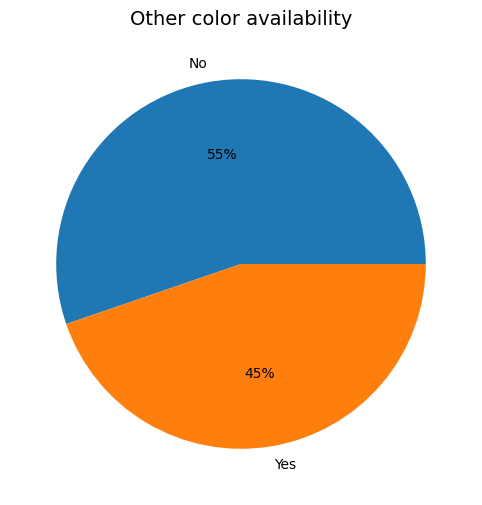

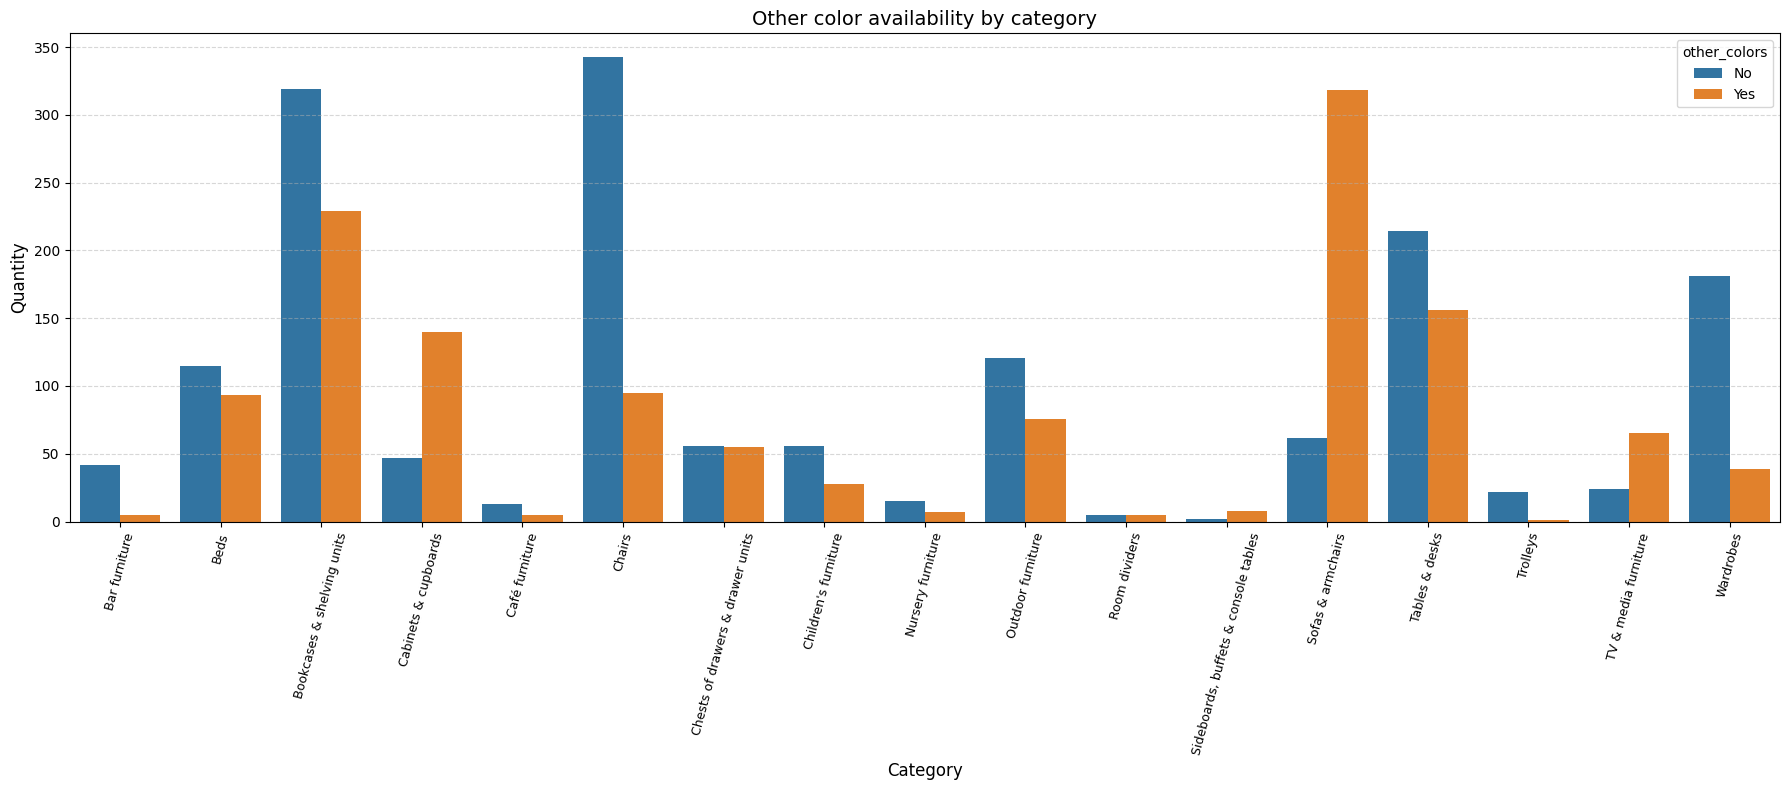

In [ ]:
other_color_count = df_ikea['other_colors'].value_counts().reset_index()
# display(other_color_count)
plt.figure(figsize=(10, 6))
other_color_count['count'].plot.pie(labels=other_color_count['other_colors'], autopct='%1.0f%%')
plt.title('Other color availability', fontsize=14)
plt.ylabel('')
plt.show()

plt.figure(figsize=(18, 8))
sns.countplot(x='category', hue='other_colors', data=df_ikea)

plt.title('Other color availability by category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Quantity', fontsize=12)
plt.xticks(rotation=75, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

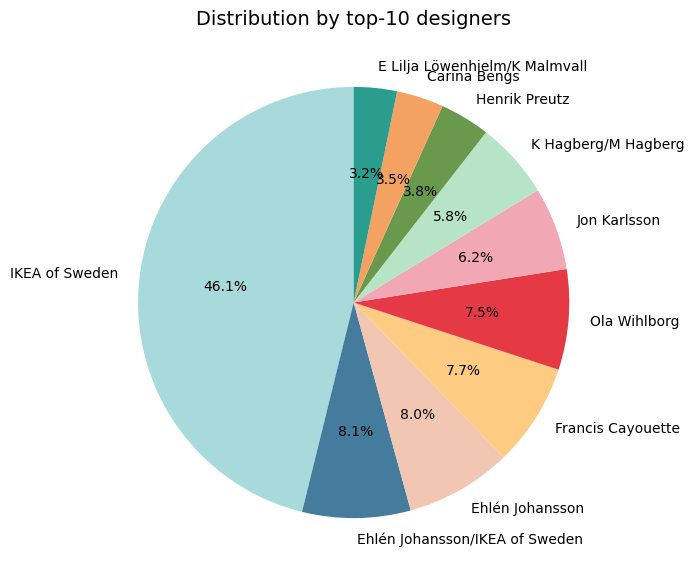

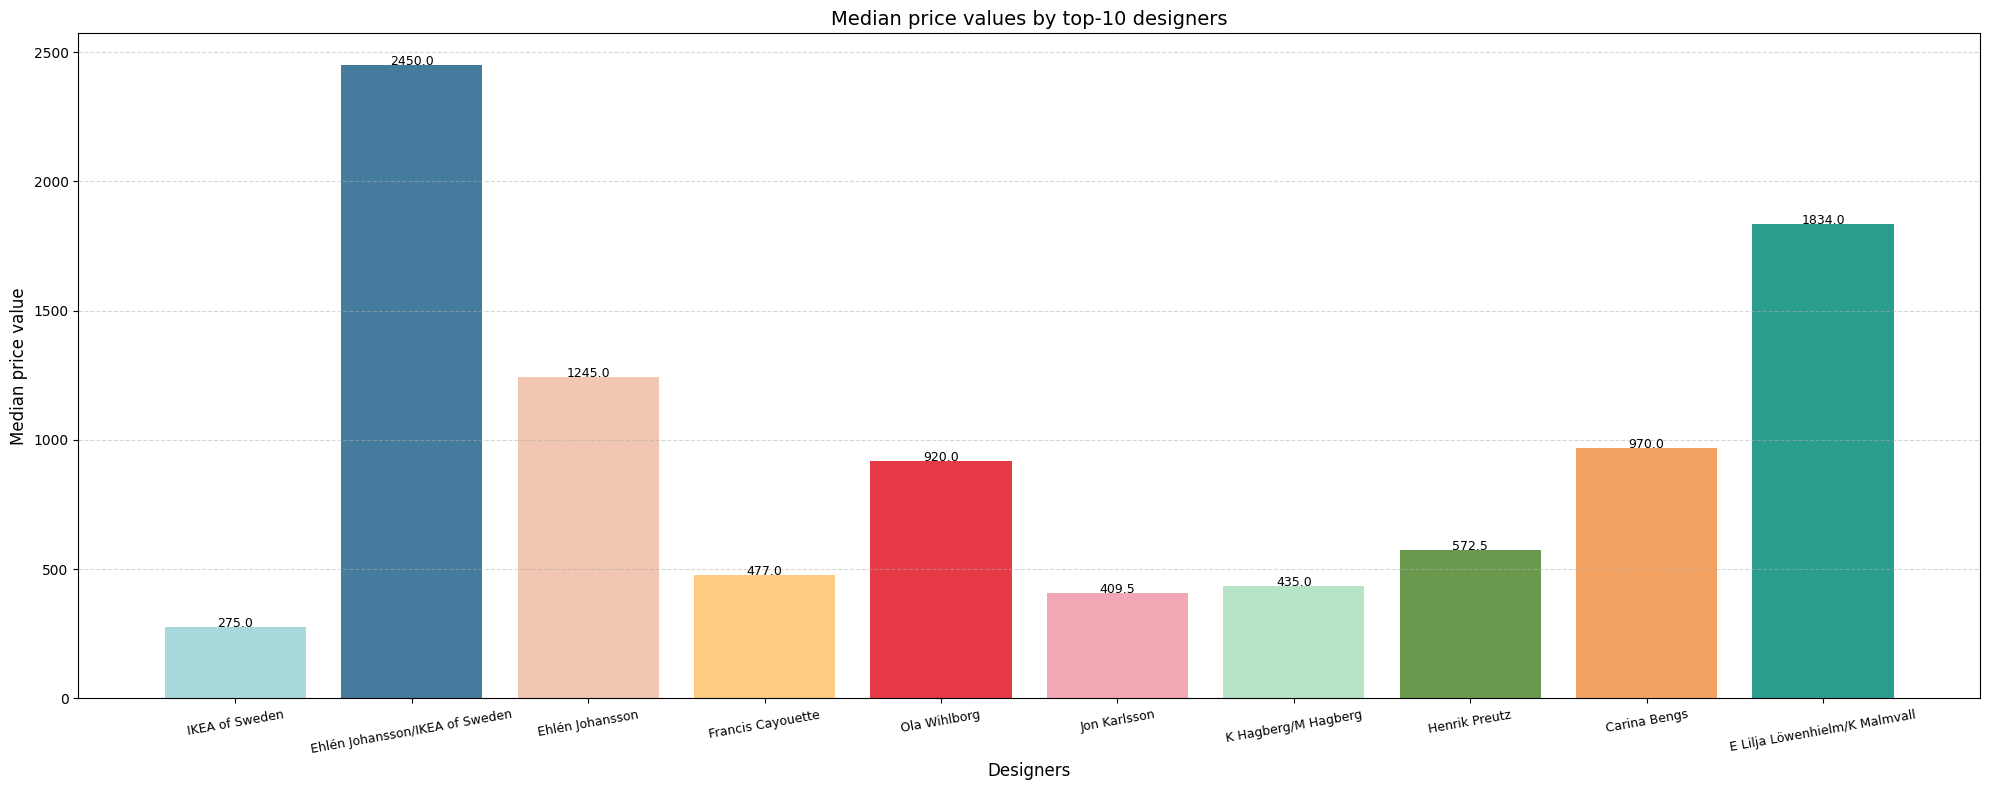

In [ ]:
df_designer_count = df_ikea['designer_clean'].value_counts().head(10).reset_index()

plt.figure(figsize=(12, 7))
df_designer_count['count'].plot(kind='pie',labels=df_designer_count['designer_clean'], colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution by top-10 designers', fontsize=14)
plt.ylabel('')
plt.show()

df1 = df_ikea.groupby('designer_clean')['price'].median().sort_values(ascending=False).reset_index()
df2 = df_ikea['designer_clean'].value_counts().reset_index()
df_designer_rank = pd.merge(df1, df2, on='designer_clean').sort_values(by='count', ascending=False).head(10)
# display(df_name_rank)

plt.figure(figsize=(20, 8))
bars = plt.bar(df_designer_rank['designer_clean'], df_designer_rank['price'], color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 1), ha='center', fontsize=9)

plt.title('Median price values by top-10 designers', fontsize=14)
plt.xlabel('Designers', fontsize=12)
plt.ylabel('Median price value', fontsize=12)
plt.xticks(rotation=10, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Обчислення статистичних характеристик для price
mean_price = df_ikea['price'].mean()
median_price = df_ikea['price'].median()
mode_price = df_ikea['price'].mode()[0]
variance_price = df_ikea['price'].var()
skew_price = df_ikea['price'].skew()
kurtosis_price = df_ikea['price'].kurt()

print('Середнє значення price:', mean_price)
print('Медіана price:', median_price)
print('Мода price:', mode_price)
print('Дисперсія price:', variance_price)
print('Скошеність price:', skew_price)
print('Куртозис price:', kurtosis_price)

Середнє значення price: 1108.7225523295072
Медіана price: 570.0
Мода price: 395.0
Дисперсія price: 1942054.3562085486
Скошеність price: 2.2946058905701867
Куртозис price: 6.256631842059702


In [ ]:
# Заповнення NaN та створення стовпчика size
df_ikea['height'] = df_ikea['height'].fillna(df_ikea['height'].median())
df_ikea['width'] = df_ikea['width'].fillna(df_ikea['width'].median())
df_ikea['depth'] = df_ikea['depth'].fillna(df_ikea['depth'].median())
df_ikea['size'] = df_ikea['width'] * df_ikea["depth"] * df_ikea["height"]

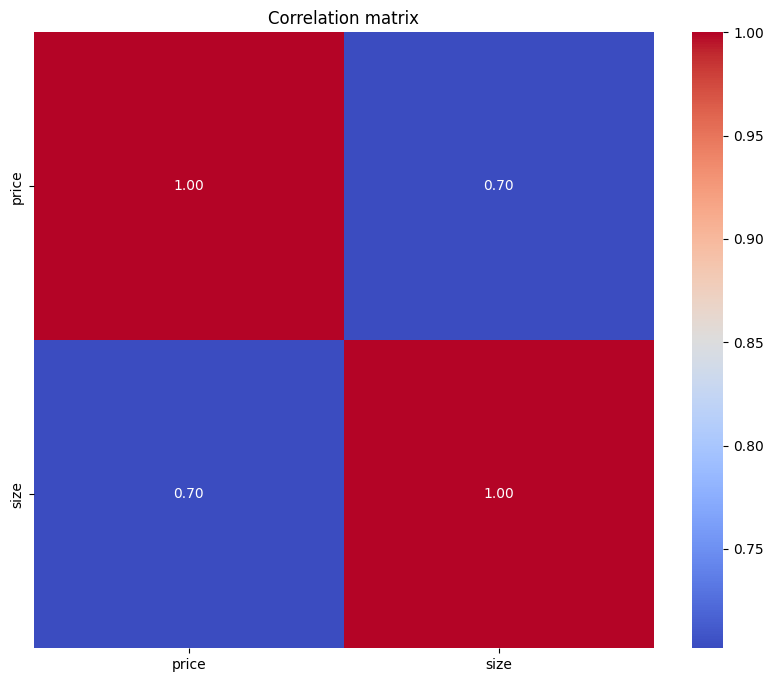

In [ ]:
# heatmap
df_price_size = df_ikea[['price', 'size']].copy()

corr = df_price_size.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

Гіпотеза №1:
ціна меблів залежить від їх розміру. Нульова гіпотеза: розмір меблім не залежить від ціни. Альтернативна гіпотеза: Розмір впливає на ціну меблів

In [ ]:
# Кореляція між ціною та розміром (шириною, висотою та довжиною)

corr, p_value = stats.pearsonr(df_ikea["price"], df_ikea["size"])
print(f"Кореляція: {corr:.2f}, p-value: {p_value:.5f}")


Нульову гіпотезу відхиляємо

In [ ]:


# Візуалізація
sns.lmplot(x="price", y="size", data=df_ikea)
plt.show()


In [ ]:
# #OLS regression model
import statsmodels.api as stsm
from statsmodels.tools import add_constant
X = df_ikea['size']
y = df_ikea['price']
X = add_constant(X)
# Fit the OLS model
model = stsm.OLS(y, X)
results = model.fit()
print(results.summary())
if results.pvalues[1] > 0.05:
    print("There is no fundamental difference in average prices.")
else:
    print("Reject the null hypothesis. There is a significant difference in average prices.")

<!-- Const = 396.3869: означає, що базова ціна становить біля 396 у.о., і при збільшенні розміру меблів на одиницю, ціна збільшується на 0,001 -->

<!-- R-squared = 0.493: означає, що 49.3% варіації ціни меблів пояснюється зміною розмірів -->

<!-- F-statistic = 2874;Коєфіцієнт кореляції = 0.7;p-value=0.0: означає, що модель значуща і змінні price тв size, котрі є незалежні, впливають одна на одну -->

In [ ]:
import statsmodels.api as sm
X = df_ikea[['size']]
y = df_ikea['price']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(f"t-value:\n{model.tvalues}")
print(f"p-value:\n{model.pvalues}")

Як висновок, приймаємо альтернативну гіпотезу: Розмір впливає на ціну меблів

Гіпотеза №2: Доступність декількох кольорів валиває на ціну. Нульова гіпотеза: Доступність декількох кольорів не залежить від ціни. Альтернативна гіпотеза: Доступність декількох кольорів впливає на ціну меблів

In [ ]:
one_color = df_ikea[df_ikea['other_colors'] == 'Yes']['price']
multiple_colors = df_ikea[df_ikea['other_colors'] == 'No']['price']

t_stat,p_value = stats.ttest_ind(one_color, multiple_colors, equal_var=False)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference in average prices.")
else:
    print("There is no fundamental difference in average prices.")

Нульову гіпотезу відхиляємо

In [ ]:
u_statistic, p_value = stats.mannwhitneyu(one_color, multiple_colors)
print(f"U-statistic: {u_statistic}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Accept the alternative hypothesis")
else:
    print("Reject the alternative hypothesis")

Як висновок, приймаємо альтернативну гіпотезу: наявність декількох кольорів впливає на розмір ціни

4.machine learning

In [ ]:
import sklearn as sk
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error

In [ ]:
X = sm.add_constant(df_ikea[['size']])
Y = df_ikea['price']

model = sm.OLS(Y, X).fit()
print(model.summary())


In [ ]:
predictions = model.predict()

plt.figure(figsize=(10, 6))

sns.scatterplot(x=X['size'], y=Y, color='skyblue', label='Data')
plt.plot(X['size'], predictions, color='purple', label='Regression Line')
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Linear regression: Size vs Price')
plt.legend()
plt.show()



In [ ]:
X1 = df_ikea[['name', 'category', 'other_colors', 'designer_clean', 'size']]
X2 = df_ikea[['name', 'category', 'other_colors', 'designer_clean', 'width', 'height', 'depth']]
features = {'X1': X1, 'X2': X2}

y = df_ikea['price']

In [ ]:
def split_to_train_test(features: dict, y: pd.Series) -> dict:
  res = {}
  for feature_name, feature_values in features.items():
    X_train, X_test, y_train, y_test = train_test_split(feature_values, y, test_size = 0.2, random_state = 42)
    res[feature_name] = (X_train, X_test, y_train, y_test)
  return res

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
def best_regressor(features, y):
  models = [
      sk.linear_model.LinearRegression(n_jobs=-1),
      sk.linear_model.RidgeCV(),
      sk.linear_model.LassoCV(n_jobs=-1),
      sk.neighbors.KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
      sk.tree.DecisionTreeRegressor(max_depth=7, random_state=42),
      RandomForestRegressor(random_state=42, n_jobs=-1),
      GradientBoostingRegressor()
  ]
  TestModels = pd.DataFrame()
  res = {}

  for model in models:
    for feature_name, feature_value in split_to_train_test(features, y).items():
      m = str(model)
      tmp = {}
      tmp['Model'] = m[:m.index('(')]+'['+ feature_name +']'
      X_train, X_test, y_train, y_test = feature_value
      column_transformer = ColumnTransformer(transformers=[
          ('num', numeric_transformer, X_train.select_dtypes(include=['float64']).columns),
          ('cat', categorical_transformer, X_train.select_dtypes(include=['object']).columns)
      ])
      model_pipeline = Pipeline(steps=[
          ('preprocessor', column_transformer),
          ('classifier', model)
      ])
      model_pipeline.fit(X_train, y_train)
      tmp['R^2'] = '{:.5f}'.format(model_pipeline.score(X_test, y_test))
      tmp['RMSE'] = '{:.5f}'.format(np.sqrt(sk.metrics.mean_squared_error(model_pipeline.predict(X_test), y_test)))
      tmp['MSE'] = '{:.5f}'.format(sk.metrics.mean_squared_error(model_pipeline.predict(X_test), y_test))
      TestModels = pd.concat([TestModels, pd.DataFrame([tmp])])

  TestModels.set_index('Model', inplace=True)
  res['model'] = TestModels
  return res

In [ ]:
test_regressor = best_regressor(features, y)
test_regressor['model'].sort_values(by='R^2', ascending=False)

5.GridSearchCV tunning for RandomForestRegressor[X1]

In [ ]:
X_train, X_test, y_train, y_test = split_to_train_test(features, y)['X2']

column_transformer = ColumnTransformer(transformers=[
          ('num', numeric_transformer, X_train.select_dtypes(include=['float64']).columns),
          ('cat', categorical_transformer, X_train.select_dtypes(include=['object']).columns)
      ])

rfr_grid = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('grid_search', GridSearchCV(
        RandomForestRegressor(),
        param_grid={

            'n_estimators': [10, 25, 50, 100, 150, 200, 500],
            'max_depth': [10, 20, 30, 50, 100],

            # 'n_estimators': [10, 25, 50],
            # 'max_depth': [10, 30, 100],

            'max_features': ['sqrt', 'log2']
        },
        cv=5,
        n_jobs=-1,
        verbose=0
    ))
])


rfr_grid.fit(X_train, y_train)


grid_search = rfr_grid.named_steps['grid_search']
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")
print('R^2: {:.5f}'.format(sk.metrics.r2_score(y_test, rfr_grid.predict(X_test))))
print('MAE: {:.5f}'.format(sk.metrics.mean_absolute_error(y_test, rfr_grid.predict(X_test))))
print('RMSE: {:.5f}'.format(np.sqrt(sk.metrics.mean_squared_error(y_test, rfr_grid.predict(X_test)))))


In [ ]:
from logging import error
X_train, X_test, y_train, y_test = split_to_train_test(features, y)['X2']

num_features = X_train.select_dtypes(include=['float64']).columns
cat_features = column_transformer.named_transformers_['cat'].get_feature_names_out(
    X_train.select_dtypes(include=['object']).columns
)
feature_name = np.concatenate([num_features, cat_features])
f_importance = {}
for feat, importance in zip(feature_name,grid_search.best_estimator_.feature_importances_):
    f_importance[feat] = importance

feat = pd.DataFrame(f_importance, index=[0])
feat_df = pd.melt(feat, var_name='Feature', value_name='score')

def feature_norm(string):
  val = string.split('_')[0]
  return val
feat_df['feature'] = feat_df['Feature'].apply(feature_norm)
print(feat_df.groupby('feature').sum())

sorted = feat_df.groupby('feature').sum().sort_values(by='score', ascending=False).reset_index()
ax = sns.barplot(data=feat_df, x='feature', y='score', hue = 'feature', estimator='sum', errorbar=None, order=sorted['feature'])
ax.bar_label(ax.containers[0], fontsize=12, fmt='{:,.2f}');
ax.bar_label(ax.containers[1], fontsize=12, fmt='{:,.2f}');
ax.bar_label(ax.containers[2], fontsize=12, fmt='{:,.2f}');
ax.bar_label(ax.containers[3], fontsize=12, fmt='{:,.2f}');
ax.bar_label(ax.containers[4], fontsize=12, fmt='{:,.2f}');
ax.bar_label(ax.containers[5], fontsize=12, fmt='{:,.2f}');
ax.bar_label(ax.containers[5], fontsize=12, fmt='{:,.2f}');
ax.bar_label(ax.containers[6], fontsize=12, fmt='{:,.2f}');

 RandomForestRegressor Cross-Validation

In [ ]:

model_pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', RandomForestRegressor(n_estimators=50, max_depth=100, max_features='sqrt', n_jobs=-1))
])

cv_5 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_6 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_7 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_8 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_9 = KFold(n_splits=5, shuffle=True, random_state=42)

# cv_values = {cv_5,cv_6,cv_7,cv_8,cv_9}



score_5 = cross_val_score(model_pipeline, X2, y, scoring='r2', cv=cv_5)
score_6 = cross_val_score(model_pipeline, X2, y, scoring='r2', cv=cv_6)
score_7 = cross_val_score(model_pipeline, X2, y, scoring='r2', cv=cv_7)
score_8 = cross_val_score(model_pipeline, X2, y, scoring='r2', cv=cv_8)
score_9 = cross_val_score(model_pipeline, X2, y, scoring='r2', cv=cv_9)

cv_scores = {
    5: score_5,
    6: score_6,
    7: score_7,
    8: score_8,
    9: score_9
}

k_values = list(cv_scores.keys())
mean_scores = [np.mean(cv_scores[k]) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_scores, marker='o', linestyle='-', color='mediumblue')
plt.title('Avarage R² for different fold number', fontsize=14)
plt.xlabel('Folds', fontsize=12)
plt.ylabel('Avarage R^2', fontsize=12)
plt.grid(True)
plt.xticks(k_values)
plt.ylim(0.75, 0.9)  # за потреби можна підлаштувати діапазон
plt.show()


In [ ]:
sorted_modelsR^2 = test_regressor['model'].sort_values(by='R^2', ascending=True)

# Побудова графіка
plt.figure(figsize=(10, 6))
plt.bar(sorted_models.index, sorted_models['R^2'])
plt.xlabel('Model')
plt.ylabel('R^2')
plt.title('R^2 for different models (sorted)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
sorted_modelsMSE = test_regressor['model'].sort_values(by='MSE', ascending=True)

# Побудова графіка
plt.figure(figsize=(10, 6))
plt.bar(sorted_modelsMSE.index, sorted_modelsMSE['MSE'], color='green')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.title('MSE for different models (sorted)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
sorted_modelsRMSE = test_regressor['model'].sort_values(by='RMSE', ascending=True)

# Побудова графіка
plt.figure(figsize=(10, 6))
plt.bar(sorted_modelsRMSE.index, sorted_modelsRMSE['RMSE'], color='gold')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE for different models (sorted)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()